# Plot results

In [ ]:
import numpy as np
import pandas as pd
import os
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch

In [ ]:
n = 100
resample_scale = 1.
coverages = {}
lengths = {}
for nu_sq in [.0, .1]:
    if nu_sq > 0:
        methods = ['naive', 'splitting', 'nf']
    else:
        methods = ['naive', 'nf']
    for signal_fac in [.0, .1, .2]:
        for key in methods:
            coverages[(nu_sq, signal_fac, key)] = []
            lengths[(nu_sq, signal_fac, key)] = []
        savepath = f'experiments/results/poly/poly_{n}_4_signal_{signal_fac}_nusq_{nu_sq}_train_2000_val_500_hidden_8'

        count = 0
        for seed in range(2000):
            try:
                with open(os.path.join(savepath, f"{seed}.pkl"), 'rb') as f:
                    res = pickle.load(f)
            except:
                continue
            count += 1
            for key in methods:
                coverages[(nu_sq, signal_fac, key)].append(res['coverages'][key].mean())
                lengths[(nu_sq, signal_fac, key)].append(np.mean(res['intervals'][key][:, 1] - res['intervals'][key][:, 0]))

            if lengths[(nu_sq, signal_fac, 'nf')][-1] == np.inf:
                print(seed, nu_sq, signal_fac)
                print(res['intervals']['nf'])
        print(signal_fac, nu_sq, 'total:', count)

0.0 0.0 total: 92
0.1 0.0 total: 185
0.2 0.0 total: 422
0.0 0.1 total: 83
0.1 0.1 total: 166
0.2 0.1 total: 388


In [3]:
max_len = 422
for key, item in coverages.items():
    if len(item) < max_len:
        item += [np.nan] * (max_len - len(item))
    coverages[key] = item[:max_len]

for key, item in lengths.items():
    if len(item) < max_len:
        item += [np.nan] * (max_len - len(item))
    lengths[key] = item[:max_len]

In [4]:
df_cover = pd.DataFrame(coverages).melt().rename(columns={'variable_0': 'nusq', 'variable_1': 'signal', 'variable_2': 'method', 'value': 'coverage'})
df_len = pd.DataFrame(lengths).melt().rename(columns={'variable_0': 'nusq', 'variable_1': 'signal', 'variable_2': 'method', 'value': 'length'})

In [5]:
color_list = {
    'naive': '#999999',
    'nf': '#31a354',
    'splitting': '#756bb1'
}
methods = ['naive', 'splitting', 'nf']

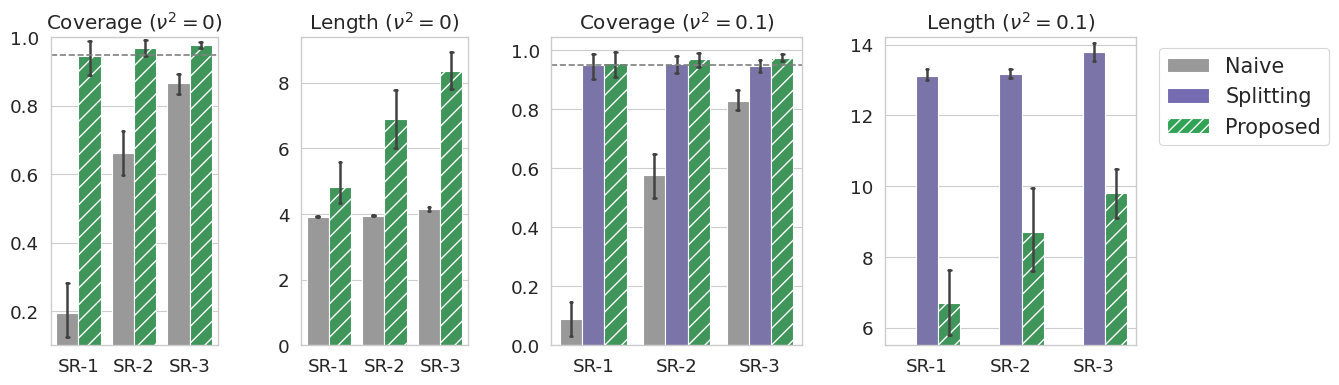

In [ ]:
sns.set_theme(context='paper', style='whitegrid', font_scale=1.5)
fig = plt.figure(figsize=(14, 4))  # width x height in inches
widths = [2, 2, 3, 3]  # relative widths of the 4 subplots

gs = gridspec.GridSpec(1, 4, width_ratios=widths, wspace=0.4)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])
ax4 = fig.add_subplot(gs[3])
axes = [ax1, ax2, ax3, ax4]

# coverage nu=0
sns.barplot(ax=ax1, data=df_cover[df_cover['nusq'] == 0.], x='signal', hue='method', y='coverage', palette=color_list, capsize=.1)
ax1.axhline(0.95, color='grey', ls='--')
ax1.set_ylim(0.1, 1)
bars = ax1.patches
bars[3].set_hatch('//')
bars[4].set_hatch('//')
bars[5].set_hatch('//')
ax1.set_title(r'Coverage ($\nu^2=0$)')

# length nu=0
sns.barplot(ax=ax2, data=df_len[df_len['nusq'] == 0.], x='signal', hue='method', y='length', palette=color_list, capsize=.1)
bars = ax2.patches
bars[3].set_hatch('//')
bars[4].set_hatch('//')
bars[5].set_hatch('//')
ax2.set_title(r'Length ($\nu^2=0$)')

# coverage nu=.1
sns.barplot(ax=ax3, data=df_cover[df_cover['nusq'] == 0.1], x='signal', hue='method', y='coverage', hue_order=methods, palette=color_list, capsize=.1)
ax3.axhline(0.95, color='grey', ls='--')
# ax3.set_ylim(0.55, 1)

bars = ax3.patches
bars[6].set_hatch('//')
bars[7].set_hatch('//')
bars[8].set_hatch('//')
ax3.set_title(r'Coverage ($\nu^2=0.1$)')

# length nu=.1
sns.barplot(ax=ax4, data=df_len[df_len['nusq'] == 0.1], x='signal', hue='method', y='length', hue_order=methods, palette=color_list, capsize=.1)
bars = ax4.patches
bars[6].set_hatch('//')
bars[7].set_hatch('//')
bars[8].set_hatch('//')
ax4.set_title(r'Length ($\nu^2=0.1$)')
ax4.set_ylim(5.5, 14.2)

for ax in axes:
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xticks([0, 1, 2], ['SR-1', 'SR-2', 'SR-3'])
    ax.legend().remove()


labels = ['Naive', 'Splitting', 'Proposed']
colors = {
    'Naive': '#999999',
    'Proposed': '#31a354',
    'Splitting': '#756bb1'
}
hatches = {
    'Naive': '',
    'Proposed': '///',
    'Splitting': ''
}

legend_patches = [
    Patch(facecolor=colors[m], hatch=hatches[m], edgecolor=None, label=m)
    for m in labels
]

plt.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=15)
